# Pilot win-rate analysis

Homogeneous vs. heterogeneous multi-agent paper review — **Stage 1 pilot** results.

This notebook reads `eval/results/<run-set>/win_rate.json` and renders the overall
ranking, the capability precondition, role-localization, and the assignment contrast.
It is parametrised by `RUN_SET` (cell below), so the same notebook can be re-run on the
held-out `full` set once that exists.

**Pilot setup:** 12 configs (3 homogeneous references + 9 heterogeneous) × 5 papers,
position-debiased side-by-side judging (both presentation orders). Pool: `A = qwen/qwen3-32b`,
`B = mistral-small-3.2-24b`, `C = llama-3.3-70b`. Each config is a 4-tuple
`(leader, clarity, experiments, impact)`.

> Pilot caveats: a **single** judge (`gpt-5-mini`; `deepseek-v3.2` not run) over **5**
> papers. Good enough to *prune*, not to make significance claims — that is what the
> 25-paper / 2-judge `full` run is for.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUN_SET = "pilot"  # <- swap to "full" once the held-out run exists

# Locate the project root (walk up until we find eval/) so the notebook runs
# regardless of the kernel's working directory.
ROOT = Path.cwd()
while not (ROOT / "eval").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

RESULTS = ROOT / "eval" / "results" / RUN_SET / "win_rate.json"
BATCHES = ROOT / "eval" / "batches.json"
FIG_DIR = ROOT / "eval" / "analysis" / "figures" / RUN_SET
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Consistent colours: references (homogeneous) vs heterogeneous; and per-model.
C_REF, C_HET = "#888888", "#4C72B0"
MODEL_COLORS = {"A": "#4C72B0", "B": "#DD8452", "C": "#55A868"}  # qwen / mistral / llama

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

wr = json.loads(RESULTS.read_text())
batch = json.loads(BATCHES.read_text())[RUN_SET]
pool = batch["pool"]                       # letter -> slug
slug_to_letter = {v: k for k, v in pool.items()}
ROLES = ("leader", "clarity", "experiments", "impact")


def letter(value: str) -> str:
    """Map a config role value (pool key OR raw slug) to its pool letter."""
    if value in pool:
        return value
    return slug_to_letter.get(value, value)


def tuple_letters(cfg: str) -> tuple[str, ...]:
    m = batch["configs"][cfg]
    return tuple(letter(m[r]) for r in ROLES)


rows = []
for c in wr["per_config"]:
    t = tuple_letters(c)
    rows.append({
        "config": c,
        "tuple": ",".join(t),
        "leader": t[0], "clarity": t[1], "experiments": t[2], "impact": t[3],
        "homogeneous": len(set(t)) == 1,
        "win_rate": wr["per_config"][c]["overall"],
    })

df = pd.DataFrame(rows).sort_values("win_rate", ascending=False).reset_index(drop=True)

judges = ", ".join(wr["judges"])
n_papers = len({rc["paper_id"] for rc in wr["raw_comparisons"]})
best_homo = df.loc[df["homogeneous"], "win_rate"].max()

print(f"run-set    : {RUN_SET}")
print(f"judge(s)   : {judges}")
print(f"papers     : {n_papers}")
print(f"configs    : {len(df)}  ({int(df['homogeneous'].sum())} homogeneous references)")
print(f"comparisons: {len(wr['raw_comparisons'])}  ({len(wr['pairwise'])} unordered pairs x 2 orders)")
print(f"best homogeneous win-rate: {best_homo:.3f}")

run-set    : pilot
judge(s)   : openai/gpt-5-mini
papers     : 5
configs    : 12  (3 homogeneous references)
comparisons: 660  (66 unordered pairs x 2 orders)
best homogeneous win-rate: 0.809


## 1. Overall ranking

Win-rate = share of head-to-head judgments a config wins (ties count 0.5), aggregated
across every opponent, paper, judge, and presentation order. The dashed line is the best
homogeneous reference — anything to its right is a heterogeneous config that beats "just
use the strongest single model everywhere".

In [2]:
disp = df.copy()
disp.index = np.arange(1, len(disp) + 1)
disp["kind"] = np.where(disp["homogeneous"], "reference", "heterogeneous")
disp[["config", "tuple", "kind", "win_rate"]]

,config,tuple,kind,win_rate
1,specialist,"A,B,A,C",heterogeneous,0.836364
2,All-A,"A,A,A,A",reference,0.809091
3,swap_experiments,"B,B,A,B",heterogeneous,0.740909
4,rot_2,"B,C,A,B",heterogeneous,0.677273
5,swap_leader,"A,B,B,B",heterogeneous,0.609091
6,swap_clarity,"B,A,B,B",heterogeneous,0.495455
7,rot_3,"B,B,C,A",heterogeneous,0.481818
8,swap_impact,"B,B,B,A",heterogeneous,0.477273
9,anti_specialist,"B,A,C,B",heterogeneous,0.436364
10,All-B,"B,B,B,B",reference,0.213636


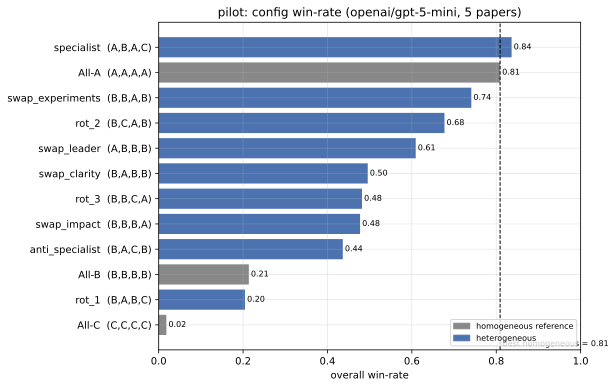

In [3]:
d = df.sort_values("win_rate")  # ascending so best sits at the top of a barh
colors = [C_REF if h else C_HET for h in d["homogeneous"]]
labels = [f"{c}  ({t})" for c, t in zip(d["config"], d["tuple"])]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.barh(labels, d["win_rate"], color=colors)
ax.axvline(best_homo, ls="--", color="black", lw=1)
ax.text(best_homo, -0.6, f" best homogeneous = {best_homo:.2f}", fontsize=8, va="top")
for y, v in enumerate(d["win_rate"]):
    ax.text(v + 0.005, y, f"{v:.2f}", va="center", fontsize=8)
ax.set_xlim(0, 1.0)
ax.set_xlabel("overall win-rate")
ax.set_title(f"{RUN_SET}: config win-rate ({judges}, {n_papers} papers)")
handles = [plt.Rectangle((0, 0), 1, 1, color=C_REF),
           plt.Rectangle((0, 0), 1, 1, color=C_HET)]
ax.legend(handles, ["homogeneous reference", "heterogeneous"], loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "ranking.png", bbox_inches="tight")
plt.show()

## 2. Capability precondition

Before reading anything into heterogeneity, check the spread of the homogeneous
references. If one model runs away, every heterogeneous result must be framed relative
to it (per `PLAN.md`).

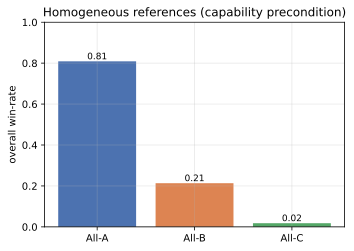

spread: {'All-A': 0.809, 'All-B': 0.214, 'All-C': 0.018}


In [4]:
homo = df[df["homogeneous"]].copy()
homo["model"] = homo["leader"]  # all four roles share one model
homo = homo.sort_values("win_rate", ascending=False)

fig, ax = plt.subplots(figsize=(5, 3.6))
bars = ax.bar(homo["config"], homo["win_rate"],
              color=[MODEL_COLORS[m] for m in homo["model"]])
for b, v in zip(bars, homo["win_rate"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
ax.set_ylim(0, 1.0)
ax.set_ylabel("overall win-rate")
ax.set_title("Homogeneous references (capability precondition)")
fig.tight_layout()
fig.savefig(FIG_DIR / "capability.png", bbox_inches="tight")
plt.show()

print("spread:", {r.config: round(r.win_rate, 3) for r in homo.itertuples()})

## 3. Localization — which seat's model matters?

Colour each config by the model sitting in the **experiments** seat. If the high-win-rate
configs cluster on one model, that seat is doing the work. The mean win-rate grouped by
experiments-seat model makes the effect explicit.

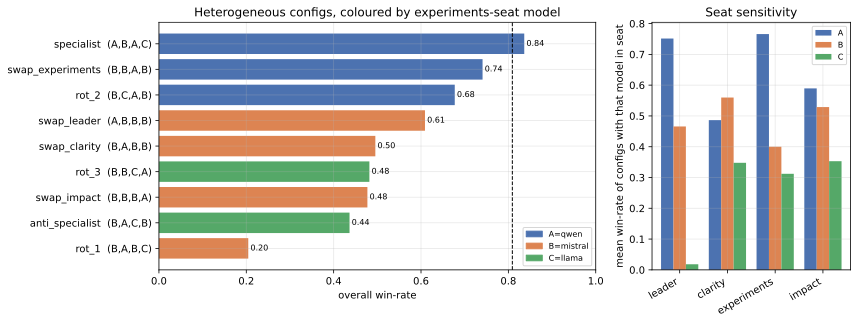

mean win-rate by (seat, model):


,A,B,C
leader,0.752,0.466,0.018
clarity,0.486,0.560,0.348
experiments,0.766,0.400,0.312
impact,0.589,0.529,0.353


In [5]:
het = df[~df["homogeneous"]].sort_values("win_rate")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [2.2, 1]})

# (a) heterogeneous configs coloured by the model in the experiments seat
ax = axes[0]
labels = [f"{c}  ({t})" for c, t in zip(het["config"], het["tuple"])]
ax.barh(labels, het["win_rate"], color=[MODEL_COLORS[m] for m in het["experiments"]])
ax.axvline(best_homo, ls="--", color="black", lw=1)
for y, v in enumerate(het["win_rate"]):
    ax.text(v + 0.005, y, f"{v:.2f}", va="center", fontsize=8)
ax.set_xlim(0, 1.0)
ax.set_xlabel("overall win-rate")
ax.set_title("Heterogeneous configs, coloured by experiments-seat model")
handles = [plt.Rectangle((0, 0), 1, 1, color=MODEL_COLORS[m]) for m in ("A", "B", "C")]
ax.legend(handles, ["A=qwen", "B=mistral", "C=llama"], loc="lower right", fontsize=8)

# (b) mean win-rate by which model fills each seat
ax = axes[1]
seat_means = {
    role: df.groupby(role)["win_rate"].mean() for role in ROLES
}
seat_df = pd.DataFrame(seat_means).T[["A", "B", "C"]]  # rows=seat, cols=model
x = np.arange(len(ROLES)); w = 0.26
for i, m in enumerate(["A", "B", "C"]):
    ax.bar(x + (i - 1) * w, seat_df[m].values, w, label=m, color=MODEL_COLORS[m])
ax.set_xticks(x); ax.set_xticklabels(ROLES, rotation=30, ha="right")
ax.set_ylabel("mean win-rate of configs with that model in seat")
ax.set_title("Seat sensitivity")
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / "localization.png", bbox_inches="tight")
plt.show()

print("mean win-rate by (seat, model):")
seat_df.round(3)

## 4. Assignment & full pairwise matrix

`pairwise` stores each unordered pair once as the row-config's win-rate over the
column-config; the mirror cell is `1 - x` (wins + ties sum to 1). The `specialist` vs
`anti_specialist` cell is the assignment contrast: similar model set, different seating.

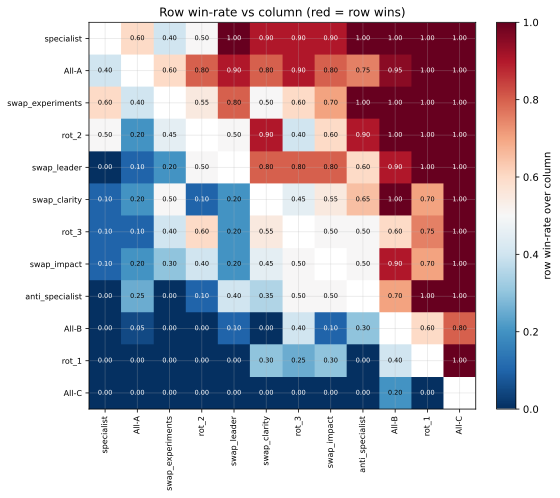

specialist beats anti_specialist head-to-head: anti wins 0.00 -> specialist wins 1.00


In [6]:
order = df["config"].tolist()  # best -> worst
idx = {c: i for i, c in enumerate(order)}
n = len(order)
M = np.full((n, n), np.nan)

for key, val in wr["pairwise"].items():
    a, b = key.split("__vs__")
    if a in idx and b in idx:
        wa = val["overall"]
        M[idx[a], idx[b]] = wa
        M[idx[b], idx[a]] = 1 - wa

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(M, cmap="RdBu_r", vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(order, rotation=90, fontsize=8)
ax.set_yticks(range(n)); ax.set_yticklabels(order, fontsize=8)
for i in range(n):
    for j in range(n):
        if not np.isnan(M[i, j]):
            ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=6.5,
                    color="white" if abs(M[i, j] - 0.5) > 0.32 else "black")
ax.set_title("Row win-rate vs column (red = row wins)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="row win-rate over column")
fig.tight_layout()
fig.savefig(FIG_DIR / "pairwise.png", bbox_inches="tight")
plt.show()

spec = wr["pairwise"].get("anti_specialist__vs__specialist", {}).get("overall")
if spec is not None:
    print(f"specialist beats anti_specialist head-to-head: anti wins {spec:.2f} -> specialist wins {1 - spec:.2f}")

## 5. Takeaways (pilot, single judge, n=5)

1. **The capability precondition dominates.** Homogeneous references spread enormously —
   `All-A` 0.81 ≫ `All-B` 0.21 ≫ `All-C` 0.02. Qwen runs away; Llama is on the floor.
   *Caveat:* `All-C` (Llama-as-leader) failed to delegate on 4/5 papers, so it degenerates
   to a stunted single-agent review — its 0.02 overstates the pure model gap.

2. **H1 barely holds and is likely within noise.** Only `specialist` (0.836) edges the best
   homogeneous `All-A` (0.809); head-to-head that is just 6 of 10 judgments. A ~0.03 margin on
   5 papers with one judge is **not** a significance claim — heterogeneity does not clearly beat
   "use the strongest single model everywhere".

3. **The clean signal is localization: `A`=qwen in the *experiments* seat is the winning move.**
   All three prune survivors (`specialist`, `swap_experiments`, `rot_2`) put A in experiments.
   The cleanest isolated case: `swap_experiments` (B,B,**A**,B) = 0.74 vs `All-B` = 0.21 — swapping
   *only* the experiments role Mistral→Qwen while the leader/writer stays Mistral jumps win-rate by
   half. The effect survives holding the final writer fixed, so it is not just leader writing style.

4. **Assignment matters, not just composition (Q2).** `specialist` beats `anti_specialist`
   ~10–0 head-to-head despite a similar model set — seating flips the outcome.
   *Soft caveat:* the multisets are not identical (`specialist` carries 2×A vs `anti`'s 1×A), so this
   partly conflates "better seats" with "more qwen".

5. **Seat-sensitivity ordering ≈ experiments > leader > clarity ≈ impact.**
   `swap_leader` (0.61) > `swap_clarity` (0.50) ≈ `swap_impact` (0.48); `rot_1` (0.21, A buried in
   clarity, C in impact) is the worst rotation. The leader seat helps, but the experiments seat helps most.

**Prune → Stage-2 `full` set:** keep the 3 references (`All-A/B/C`) + top-3 heterogeneous
(`specialist`, `swap_experiments`, `rot_2`) and score them on the held-out 25 papers with **two**
judges before any inference.